# Lab 2 Exercises

## 9/9/2025

## Ryan Waterman

In [1]:
# Imports
import torch

## Chapter 3

### Exercise 1

#### 1. Create a tensor a from list(range(9)). Predict and then check the size, offset, and stride.

In [15]:
#Create the tensor
a = torch.tensor(list(range(9)))
a

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8])

**Size is dimensionality of the tensor. In this case, the tensor was instantiated from a flat list, therefore it is 1 dimensional. The list contained 9 elements, so the size will be [9].**

In [16]:
a.size()

torch.Size([9])

**Offset represents the contiguous memory storage containing the tensor. Calling the function without an argument will return the first element in the memory block, which is 0.**

In [28]:
a.storage_offset()

0

**Stride is the jump required to go from one element to the next in a tensor. In this case, our tensor is one dimensional and the range from which it was composed has a step size of 1. As a result, the stride will be 1.**

In [18]:
a.stride()

(1,)

#### 2. Create  a  new  tensor  using  b  =  a.view(3,  3).  What  does  view  do?  Check that a and b share the same storage.

In [20]:
b = a.view(3,3)
b

tensor([[0, 1, 2],
        [3, 4, 5],
        [6, 7, 8]])

**View takes the data contained within tensor a and dimensions based on the arguments passed to the function. The underlying data is the same, but tensor b has reshaped it to a 3x3 matrix.**

In [23]:
print(b.storage().data_ptr()==a.storage().data_ptr())

True


C:\Users\water\AppData\Local\Temp\ipykernel_27416\23682572.py:1: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  print(b.storage().data_ptr()==a.storage().data_ptr())


#### 3. Create a tensor c = b[1:,1:]. Predict and then check the size, offset, and stride.

In [24]:
c = b[1:,1:]

**The size of c will be [2,2], as the first row and column have been sliced from tensor b.**

In [25]:
print(c.size())

torch.Size([2, 2])


**The offset of c will be 4, as c is a 2x2 matrix making up the bottom right elements of b. The first value in that 2x2 matrix is 4**

In [26]:
c.storage_offset()

4

**The stride of c will be (3,1), as the jump between elements on the row axis is 3, and the jump between elements on the column axis is 1.**

In [27]:
c.stride()

(3, 1)

### Exercise 2

#### 1. Pick a mathematical operation like cosine or square root. Can you find a corresponding function in the torch library?

In [30]:
sin_a = a.sin()
sin_a

tensor([ 0.0000,  0.8415,  0.9093,  0.1411, -0.7568, -0.9589, -0.2794,  0.6570,
         0.9894])

**Mathematical operations are methods within the torch class. For example: torch.sin().**

#### 2. Apply the function element-wise to a. Why does it return an error?

In [33]:
elementwise = torch.zeros(a.size())
for idx, element in enumerate(a):
    elementwise[idx] = element.sin()

elementwise

tensor([ 0.0000,  0.8415,  0.9093,  0.1411, -0.7568, -0.9589, -0.2794,  0.6570,
         0.9894])

**Hmmm, this worked (as I expected it might). Maybe I am performing this wrong, which I think means I am doing it right :). I am going to try a few other methods to see if I can generate an error.**

In [36]:
elementwise = torch.zeros(a.size())
for idx, element in enumerate(a):
    elementwise[idx] = torch.sin(element)

elementwise

tensor([ 0.0000,  0.8415,  0.9093,  0.1411, -0.7568, -0.9589, -0.2794,  0.6570,
         0.9894])

In [37]:
torch.sin(a)

tensor([ 0.0000,  0.8415,  0.9093,  0.1411, -0.7568, -0.9589, -0.2794,  0.6570,
         0.9894])

**NOTE: I saw the Canvas announcement stating that torch now performs type conversion implicitly, which is why I wasn't getting an error.**

#### 3. What operation is required to make the function work?

In [40]:
a_retyped = a.float()
a_retyped

tensor([0., 1., 2., 3., 4., 5., 6., 7., 8.])

**In the older versions of torch, the type conversion, above, would have to be performed to cast the tensor to a floats.**

#### 4. Is there a version of your function that operates in place?

In [49]:
# now the float conversion must be performed...
a = a.float()

In [50]:
a.sin_()

tensor([ 0.0000,  0.8415,  0.9093,  0.1411, -0.7568, -0.9589, -0.2794,  0.6570,
         0.9894])

In [51]:
a

tensor([ 0.0000,  0.8415,  0.9093,  0.1411, -0.7568, -0.9589, -0.2794,  0.6570,
         0.9894])

## Chapter 4

### Exercise 1

In [122]:
import torchvision.io as io
import os
import matplotlib.pyplot as plt

#### 1. Take several pictures of red, blue, and green items with your phone or other digital camera (or download some from the internet, if a camera isn’t available).

#### 2. Load each image, and convert it to a tensor.

In [137]:
img_path = 'images'

images = [io.decode_image(f'{img_path}/{image}').float() for image in os.listdir(img_path)]

#### 3. For each image tensor, use the .mean() method to get a sense of how bright the image is.

In [124]:
for image in images:
    mean = image.mean()
    print(mean)

tensor(87.3899)
tensor(89.2129)
tensor(92.6094)
tensor(99.9660)


#### 4. Take  the  mean  of  each  channel  of  your  images.  Can  you  identify  the  red, green, and blue items from only the channel averages?

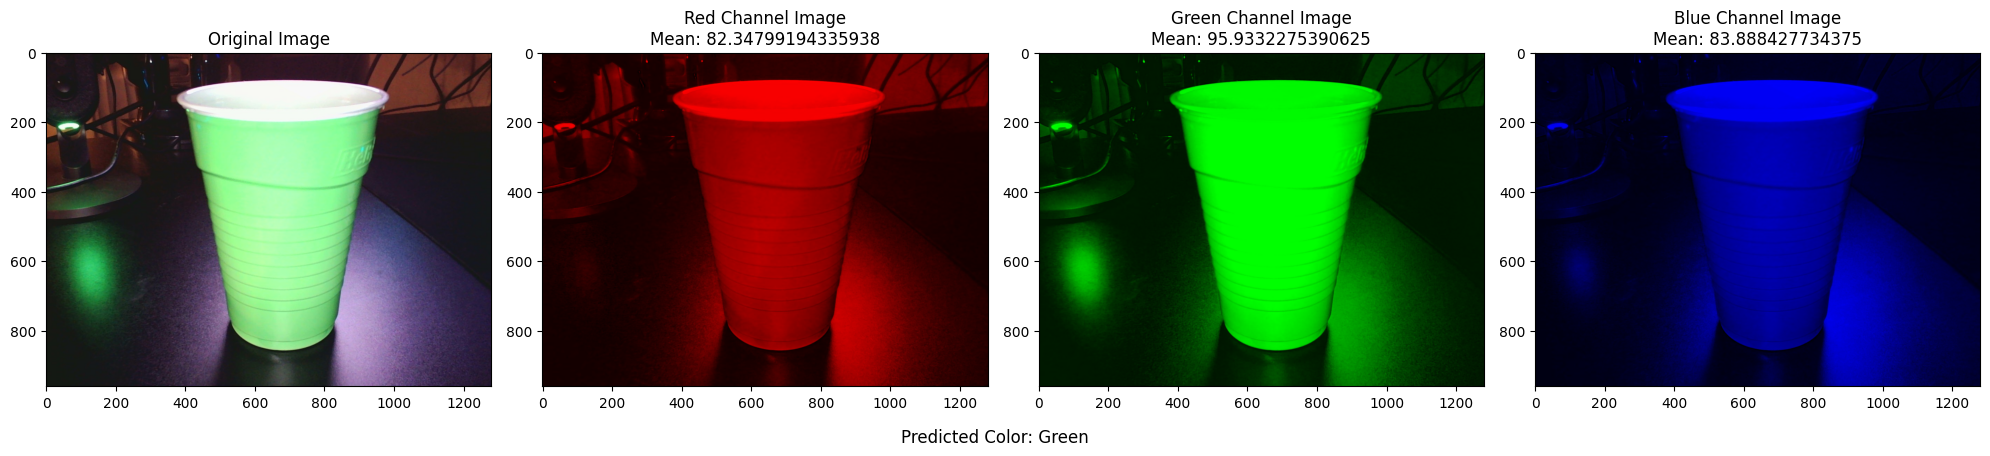

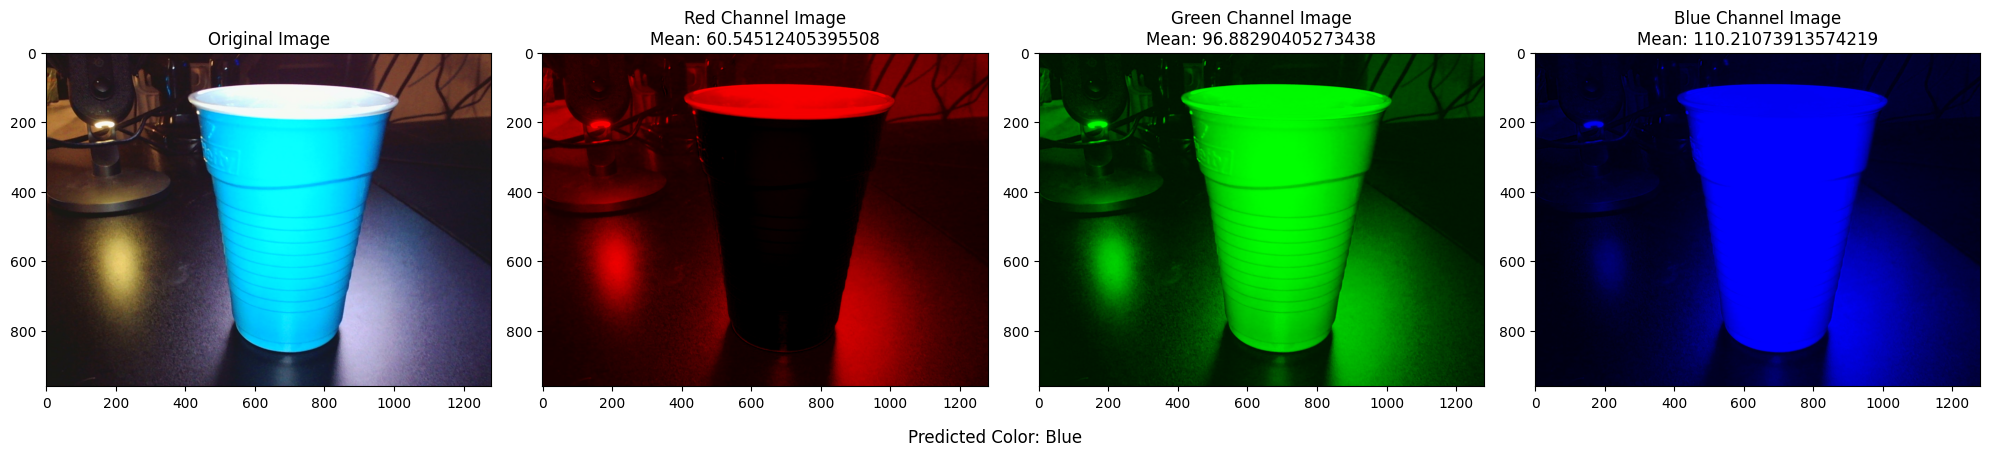

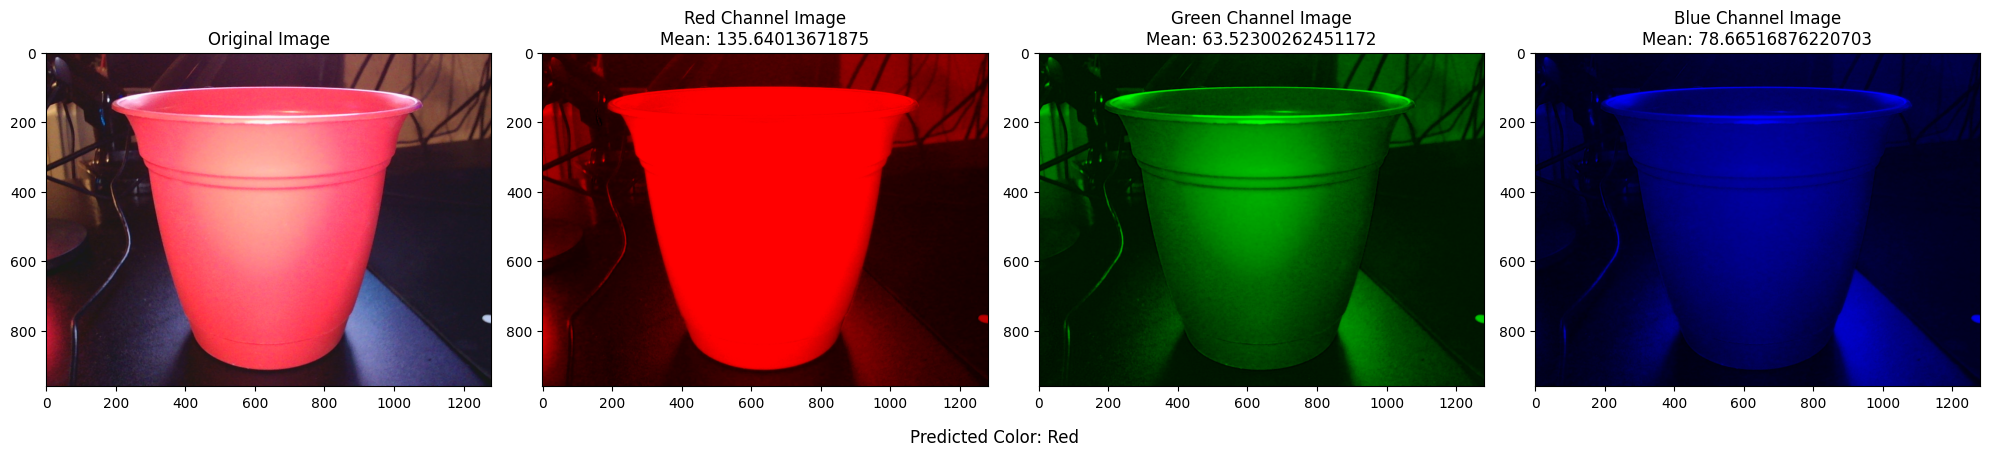

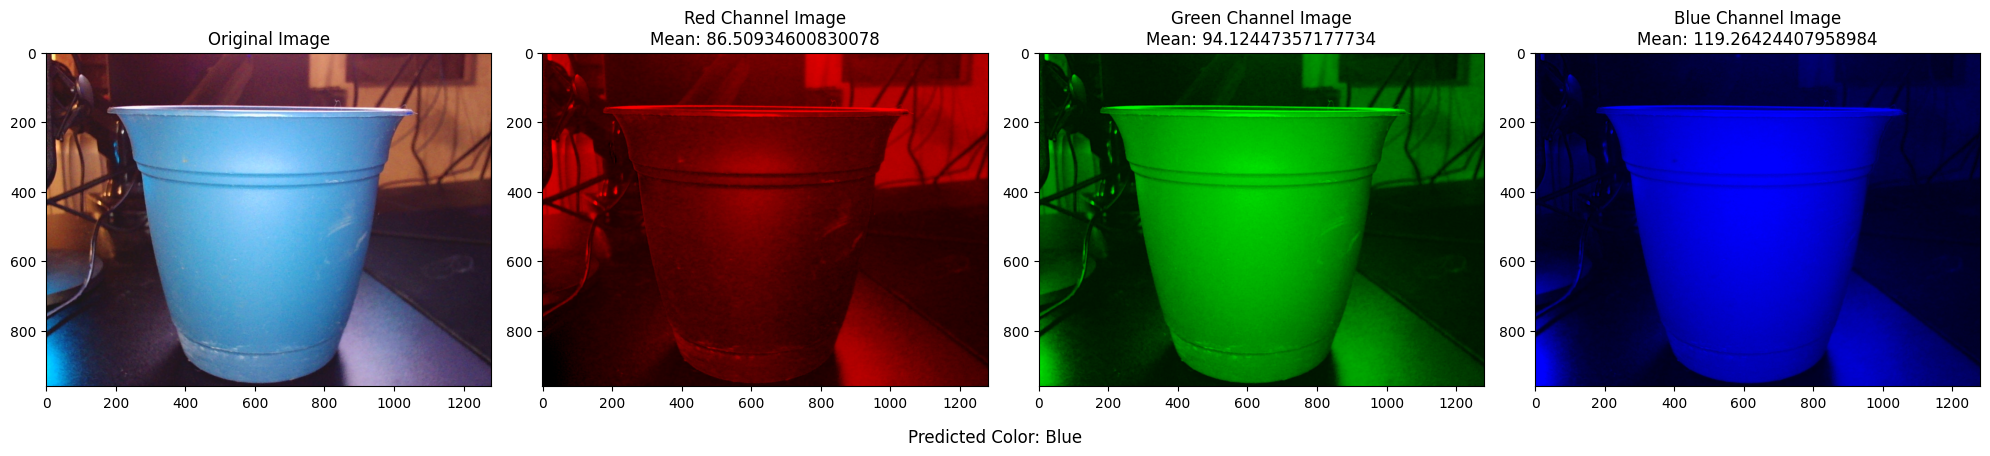

In [136]:
for image in images:
    r,g,b = image.split(1,dim=0)

    r_mean, g_mean, b_mean = r.mean(), g.mean(), b.mean()

    channel_means = {
        r_mean:'Red',
        g_mean:'Green',
        b_mean:'Blue'
    }

    max_channel = max(channel_means.keys())

    r,g,b = r.reshape(960, 1280, 1), g.reshape(960, 1280, 1), b.reshape(960, 1280, 1)

    black_channel = torch.zeros(960,1280,1)

    r = torch.cat((r, black_channel, black_channel), dim=2)
    g = torch.cat((black_channel, g, black_channel), dim=2)
    b = torch.cat((black_channel, black_channel, b), dim=2)

    # Display the image
    fig, ax = plt.subplots(1, 4, figsize = (20,15))

    ax[0].imshow(image.permute(1,2,0)/255)
    ax[1].imshow(r.permute(0,1,2)/255)
    ax[2].imshow(g.permute(0,1,2)/255)
    ax[3].imshow(b.permute(0,1,2)/255)

    ax[0].set_title('Original Image')
    ax[1].set_title(f'Red Channel Image\nMean: {r_mean}')
    ax[2].set_title(f'Green Channel Image\nMean: {g_mean}')
    ax[3].set_title(f'Blue Channel Image\nMean: {b_mean}')

    fig.suptitle(f'Predicted Color: {channel_means[max_channel]}', y=0.35)
    fig.tight_layout()



**Using the means of color channels alone, the object color was successfully predicted every time without any thresholding other image augmentation.**

## One-hot Encoding Exercise

In [146]:
import pandas as pd

In [147]:
df = pd.read_csv('data/lodgepole_data.csv')

In [148]:
df_one_hot = pd.get_dummies(df, columns=['wilderness_area','soil_type'], dtype=int)

In [149]:
df_one_hot.columns

Index(['elevation', 'aspect', 'slope', 'horizontal_distance_to_hydrology',
       'vertical_distance_to_hydrology', 'horizontal_distance_to_roadways',
       'hillshade_9am', 'hillshade_noon', 'hillshade_3pm',
       'horizontal_distance_to_fire_points', 'lodgepole_pine',
       'wilderness_area_wilderness_area_1',
       'wilderness_area_wilderness_area_2',
       'wilderness_area_wilderness_area_3',
       'wilderness_area_wilderness_area_4', 'soil_type_soil_type_1',
       'soil_type_soil_type_10', 'soil_type_soil_type_11',
       'soil_type_soil_type_12', 'soil_type_soil_type_13',
       'soil_type_soil_type_14', 'soil_type_soil_type_16',
       'soil_type_soil_type_17', 'soil_type_soil_type_18',
       'soil_type_soil_type_19', 'soil_type_soil_type_2',
       'soil_type_soil_type_20', 'soil_type_soil_type_21',
       'soil_type_soil_type_22', 'soil_type_soil_type_23',
       'soil_type_soil_type_24', 'soil_type_soil_type_25',
       'soil_type_soil_type_26', 'soil_type_soil_type_2

In [151]:
df_one_hot['wilderness_area_wilderness_area_3'].value_counts()

wilderness_area_wilderness_area_3
0    4834
1    3882
Name: count, dtype: int64